<a href="https://colab.research.google.com/github/Deepika-Ch19/Network-intrusion-detection/blob/main/network_intrusion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Read the csv file

In [4]:
import pandas as pd
filepath='/content/drive/MyDrive/Midterm_53_group.csv'
df = pd.read_csv(filepath)
df.head()

,Time,Source,No.,Destination,Protocol,Length,Info
0,0.000000,192.167.8.166,1,192.167.255.255,NBNS,92,Name query NB WPAD<00>
1,0.784682,192.167.8.166,2,192.167.255.255,NBNS,92,Name query NB WPAD<00>
2,1.169060,VMware_8a:5c:e6,3,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1
3,2.167949,VMware_8a:5c:e6,4,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1
4,3.170095,VMware_8a:5c:e6,5,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1


In [5]:
print(df.columns.tolist())


['Time', 'Source', 'No.', 'Destination', 'Protocol', 'Length', 'Info']


In [6]:
df = pd.get_dummies(df, columns=['Protocol'], drop_first=True)
df['is_query'] = df['Info'].str.contains('query', case=False).astype(int)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Time', 'Length']] = scaler.fit_transform(df[['Time', 'Length']])
df = df.drop(columns=['Info'])
df.head()


,Time,Source,No.,Destination,Length,Protocol_BROWSER,Protocol_DHCP,Protocol_DNS,Protocol_HTTP,Protocol_ICMP,...,Protocol_NBNS,Protocol_OCSP,Protocol_RARP,Protocol_SSLv2,Protocol_STUN,Protocol_TCP,Protocol_TLSv1,Protocol_TLSv1.2,Protocol_TLSv1.3,is_query
0,0.000000,192.167.8.166,1,192.167.255.255,0.001006,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,1
1,0.000624,192.167.8.166,2,192.167.255.255,0.001006,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,1
2,0.000930,VMware_8a:5c:e6,3,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
3,0.001725,VMware_8a:5c:e6,4,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
4,0.002522,VMware_8a:5c:e6,5,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0


In [7]:
from sklearn.ensemble import IsolationForest
X = df[['Time', 'Length']]
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(X)
print(df['anomaly'].value_counts())
df[df['anomaly'] == -1].head()

anomaly
 1    374460
-1     19676
Name: count, dtype: int64


,Time,Source,No.,Destination,Length,Protocol_BROWSER,Protocol_DHCP,Protocol_DNS,Protocol_HTTP,Protocol_ICMP,...,Protocol_OCSP,Protocol_RARP,Protocol_SSLv2,Protocol_STUN,Protocol_TCP,Protocol_TLSv1,Protocol_TLSv1.2,Protocol_TLSv1.3,is_query,anomaly
0,0.000000,192.167.8.166,1,192.167.255.255,0.001006,False,False,False,False,False,...,False,False,False,False,False,False,False,False,1,-1
1,0.000624,192.167.8.166,2,192.167.255.255,0.001006,False,False,False,False,False,...,False,False,False,False,False,False,False,False,1,-1
2,0.000930,VMware_8a:5c:e6,3,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,False,0,-1
3,0.001725,VMware_8a:5c:e6,4,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,False,0,-1
4,0.002522,VMware_8a:5c:e6,5,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,False,0,-1


In [8]:
from sklearn.svm import OneClassSVM
features = df[['Time','Length']]
small_sample = features.sample(n=500, random_state=42)
svm_small = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
df_sample = df.copy()
df_sample.loc[small_sample.index, 'svm_anomaly'] = svm_small.fit_predict(small_sample)
print(df['anomaly'].value_counts())
df[df['anomaly']==-1].head()

anomaly
 1    374460
-1     19676
Name: count, dtype: int64


,Time,Source,No.,Destination,Length,Protocol_BROWSER,Protocol_DHCP,Protocol_DNS,Protocol_HTTP,Protocol_ICMP,...,Protocol_OCSP,Protocol_RARP,Protocol_SSLv2,Protocol_STUN,Protocol_TCP,Protocol_TLSv1,Protocol_TLSv1.2,Protocol_TLSv1.3,is_query,anomaly
0,0.000000,192.167.8.166,1,192.167.255.255,0.001006,False,False,False,False,False,...,False,False,False,False,False,False,False,False,1,-1
1,0.000624,192.167.8.166,2,192.167.255.255,0.001006,False,False,False,False,False,...,False,False,False,False,False,False,False,False,1,-1
2,0.000930,VMware_8a:5c:e6,3,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,False,0,-1
3,0.001725,VMware_8a:5c:e6,4,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,False,0,-1
4,0.002522,VMware_8a:5c:e6,5,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,False,0,-1


In [9]:
from sklearn.neighbors import LocalOutlierFactor
features = df[['Time', 'Length']]
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_sample = df.copy()
df_sample['lof_anomaly'] = lof.fit_predict(features)
print(df_sample['lof_anomaly'].value_counts())
df_sample[df_sample['lof_anomaly'] == -1].head()


lof_anomaly
 1    374429
-1     19707
Name: count, dtype: int64


,Time,Source,No.,Destination,Length,Protocol_BROWSER,Protocol_DHCP,Protocol_DNS,Protocol_HTTP,Protocol_ICMP,...,Protocol_RARP,Protocol_SSLv2,Protocol_STUN,Protocol_TCP,Protocol_TLSv1,Protocol_TLSv1.2,Protocol_TLSv1.3,is_query,anomaly,lof_anomaly
45,0.030948,0.0.0.0,46,255.255.255.255,0.006478,False,True,False,False,False,...,False,False,False,False,False,False,False,0,-1,-1
54,0.032089,VMware_8a:5c:e6,55,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,0,-1,-1
56,0.032394,192.167.8.65,57,192.167.255.255,0.001006,False,False,False,False,False,...,False,False,False,False,False,False,False,1,-1,-1
57,0.032686,VMware_8a:a0:c6,58,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,False,False,0,-1,-1
58,0.032848,192.167.7.175,59,192.167.255.255,0.001368,False,False,False,False,False,...,False,False,False,False,False,False,False,0,-1,-1


In [10]:
import numpy as np
from sklearn.cluster import KMeans
features = df[['Time', 'Length']]
kmeans = KMeans(n_clusters=2, random_state=42)
df_sample['cluster'] = kmeans.fit_predict(features)
distances = np.linalg.norm(features - kmeans.cluster_centers_[df_sample['cluster']], axis=1)
threshold = np.percentile(distances, 95)
df_sample['kmeans_anomaly'] = (distances > threshold).astype(int)
df_sample['kmeans_anomaly'] = df_sample['kmeans_anomaly'].replace({1: -1, 0: 1})
print(df_sample['kmeans_anomaly'].value_counts())
df_sample[df_sample['kmeans_anomaly'] == -1].head()


kmeans_anomaly
 1    374429
-1     19707
Name: count, dtype: int64


,Time,Source,No.,Destination,Length,Protocol_BROWSER,Protocol_DHCP,Protocol_DNS,Protocol_HTTP,Protocol_ICMP,...,Protocol_STUN,Protocol_TCP,Protocol_TLSv1,Protocol_TLSv1.2,Protocol_TLSv1.3,is_query,anomaly,lof_anomaly,cluster,kmeans_anomaly
0,0.000000,192.167.8.166,1,192.167.255.255,0.001006,False,False,False,False,False,...,False,False,False,False,False,1,-1,1,0,-1
1,0.000624,192.167.8.166,2,192.167.255.255,0.001006,False,False,False,False,False,...,False,False,False,False,False,1,-1,1,0,-1
2,0.000930,VMware_8a:5c:e6,3,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,0,-1,1,0,-1
3,0.001725,VMware_8a:5c:e6,4,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,0,-1,1,0,-1
4,0.002522,VMware_8a:5c:e6,5,Broadcast,0.000362,False,False,False,False,False,...,False,False,False,False,False,0,-1,1,0,-1


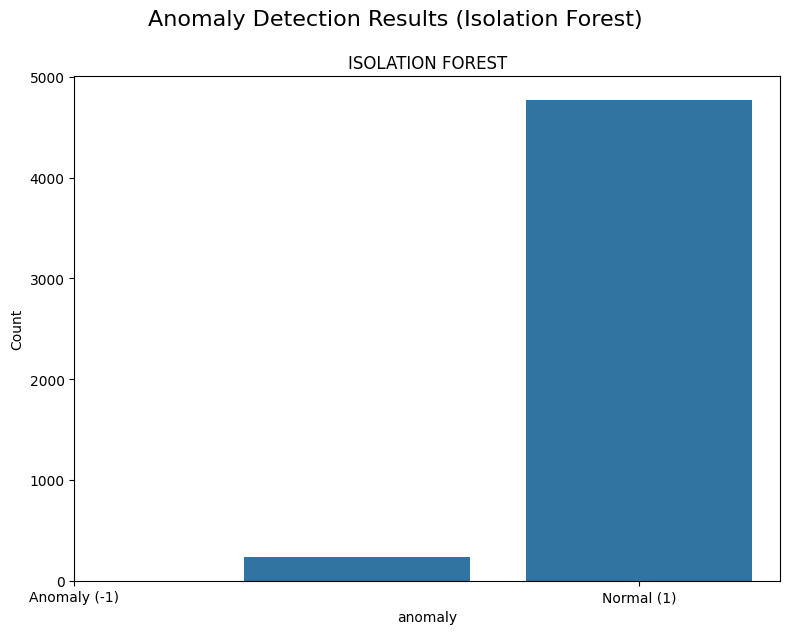

In [11]:
plt.figure(figsize=(8, 6))
models = ['anomaly']
df_sample = df.sample(n=5000, random_state=42)
for i, model in enumerate(models):
    plt.subplot(1, 1, i + 1)
    sns.countplot(x=df_sample[model])
    plt.title(model.replace("anomaly", "Isolation Forest").upper())
    plt.ylabel('Count')
    plt.xticks(ticks=[-1, 1], labels=['Anomaly (-1)', 'Normal (1)'])
    plt.tight_layout()

plt.suptitle("Anomaly Detection Results (Isolation Forest)", y=1.05, fontsize=16)
plt.show()

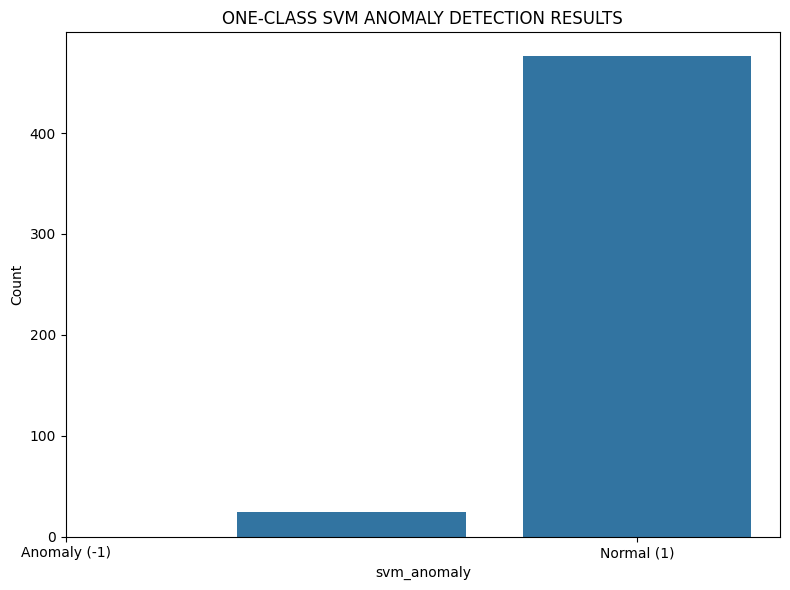

In [15]:


def plot_anomaly_results(model_name, anomaly_column):
    plt.figure(figsize=(8, 6))
    sns.countplot(x=df_sample[anomaly_column])
    plt.title(f"{model_name} Anomaly Detection Results".upper())
    plt.ylabel('Count')
    plt.xticks(ticks=[-1, 1], labels=['Anomaly (-1)', 'Normal (1)'])
    plt.tight_layout()
    plt.show()

plot_anomaly_results("One-Class SVM", 'svm_anomaly')

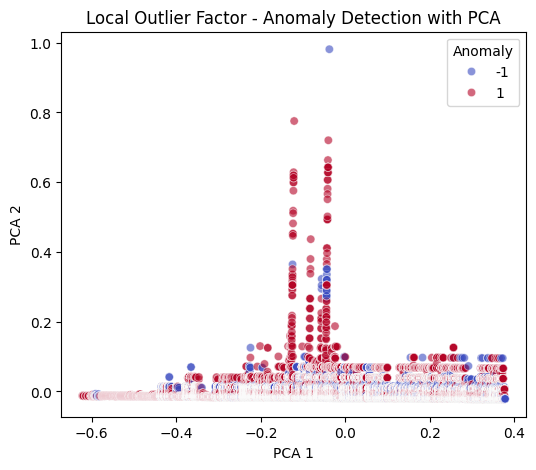

In [16]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
features = df[['Time', 'Length']]
pca = PCA(n_components=2)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_sample = df.copy()
df_sample['lof_anomaly'] = lof.fit_predict(features)


def plot_anomaly_pca(model_name, anomaly_column, features):
    pca_result = pca.fit_transform(features)
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df_sample[anomaly_column],
                    palette='coolwarm', alpha=0.6)
    plt.title(f'{model_name} - Anomaly Detection with PCA')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.legend(title='Anomaly')
    plt.show()


plot_anomaly_pca("Local Outlier Factor", 'lof_anomaly', features)

/tmp/ipython-input-17-3720676452.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


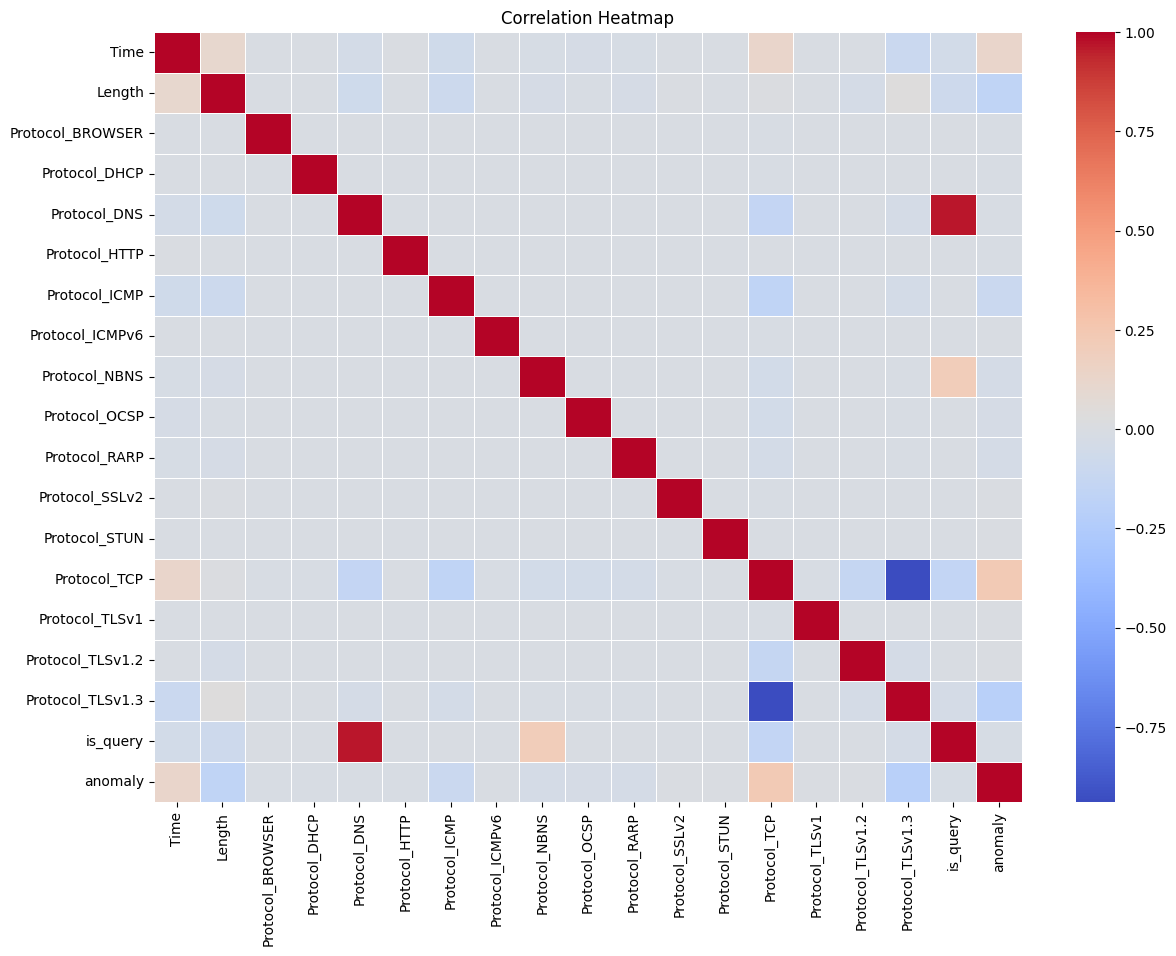

In [17]:
df = df.replace({True: 1, False: 0})
df_numeric = df.drop(columns=['Source', 'Destination', 'No.'])
plt.figure(figsize=(14, 10))
sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()
